# Demo multicorpus

Integra `MuseTrainer/library`, `SymbTr`, `PDMX` y `JAZZMUS` dentro del pipeline armonico del proyecto.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / 'src').exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / 'src').exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/janusadamuz/Documentos/Melodies')

In [2]:
INCLUDE_LIBRARY = PROJECT_ROOT / 'external' / 'library' / 'scores'
INCLUDE_SYMBTR = PROJECT_ROOT / 'external' / 'SymbTr'
INCLUDE_JAZZMUS = None  # Ejemplo: PROJECT_ROOT / 'data' / 'jazzmus_dataset'
INCLUDE_PDMX = None     # Ejemplo: Path('/ruta/local/a/PDMX_dataset')

MODEL = 'finite_hmm'    # 'finite_hmm', 'hdp_hmm' o 'both'
OBS = 'pitch_class'
SAMPLE_PER_SOURCE = 5
LIMIT = 10
K = 12
ITERS = 30
BURN_IN = 15
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'demo_multicorpus'


In [3]:
from src.analysis.library_batch import analyze_multicorpus
from src.data.multicorpus import CorpusSource

sources = []
if INCLUDE_LIBRARY:
    sources.append(CorpusSource(name='MuseTrainer', source_type='generic', root_dir=INCLUDE_LIBRARY))
if INCLUDE_SYMBTR:
    sources.append(CorpusSource(name='SymbTr', source_type='symbtr', root_dir=INCLUDE_SYMBTR))
if INCLUDE_JAZZMUS:
    sources.append(CorpusSource(name='JAZZMUS', source_type='jazzmus', root_dir=INCLUDE_JAZZMUS))
if INCLUDE_PDMX:
    sources.append(CorpusSource(name='PDMX', source_type='pdmx', root_dir=INCLUDE_PDMX))

outputs = analyze_multicorpus(
    sources=sources,
    output_dir=OUTPUT_DIR,
    obs_type=OBS,
    model=MODEL,
    limit=LIMIT,
    file_limit_per_source=SAMPLE_PER_SOURCE,
    hdp_params={'n_states': K, 'n_iters': ITERS, 'burn_in': BURN_IN, 'seed': 7},
)
outputs

/home/janusadamuz/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.1) or chardet (7.3.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


{'catalog_dir': PosixPath('/home/janusadamuz/Documentos/Melodies/outputs/demo_multicorpus/catalog'),
 'analysis_dir': PosixPath('/home/janusadamuz/Documentos/Melodies/outputs/demo_multicorpus/analysis')}

In [4]:
import pandas as pd

catalog = pd.read_csv(OUTPUT_DIR / 'catalog' / 'catalog.csv')
analysis = pd.read_csv(OUTPUT_DIR / 'analysis' / 'analysis.csv')

print('Obras catalogadas:', len(catalog))
print('Obras analizadas:', len(analysis))
display(catalog[['source_name', 'source_type', 'title', 'composer', 'genre_family', 'style_system']].head(20))
display(analysis.head(20))

Obras catalogadas: 10
Obras analizadas: 10


,source_name,source_type,title,composer,genre_family,style_system
0,MuseTrainer,generic,Bach_Minuet_in_G_Major_BWV_Anh._114.mxl,Bach,unknown,unknown
1,MuseTrainer,generic,Bach_Toccata_and_Fugue_in_D_Minor_Piano_solo.mxl,Bach,unknown,unknown
2,MuseTrainer,generic,Arabesque No. 1 in E Major,Claude Achille Debussy(1862–1918),unknown,unknown
3,MuseTrainer,generic,Twinkle Twinkle Little Star,Mozart,unknown,unknown
4,MuseTrainer,generic,Ave Maria,Schubert,unknown,unknown
5,SymbTr,symbtr,Zülfünü Tasvîr İçin,Ahmet Avni Konuk,turkish_art_music,makam
6,SymbTr,symbtr,Acem Seyir,Erol Bingöl,turkish_art_music,makam
7,SymbTr,symbtr,Çalabım Bir Şâr Yaratmış,Hacı Bayram Veli,turkish_art_music,makam
8,SymbTr,symbtr,Âşık-I Ger,Hüseyin Fahreddin Dede,turkish_art_music,makam
9,SymbTr,symbtr,Aldanma Dünya Varına,Zekâî Dede,turkish_art_music,makam


,Unnamed: 0,path,filename,title,composer,period,form,arrangement_tag,difficulty_bucket,part_count,...,usul,symbtr_form,observation_type,n_events,finite_log_likelihood,finite_active_states,finite_top_labels,finite_top_modes,finite_hmm_mean_segment_length,finite_hmm_trajectory_stability
0,0,/home/janusadamuz/Documentos/Melodies/external...,acem--kupe--duyek--zulfunu--ahmet_avni_konuk.xml,Zülfünü Tasvîr İçin,Ahmet Avni Konuk,unknown,kupe,standard,advanced,1,...,duyek,kupe,pitch_class,94,-233.394098,17,"D:madd9 (13), G:madd9 (11), F:sus2 (9), C:sus4...","F:ionian (22), D:dorian (20), G:dorian (16), C...",3.615385,1.0
1,1,/home/janusadamuz/Documentos/Melodies/external...,acem--seyir--sofyan--1--erol_bingol.xml,Acem Seyir,Erol Bingöl,unknown,seyir,standard,intermediate-advanced,1,...,sofyan,seyir,pitch_class,99,-245.884895,19,"G:madd9 (20), G:sus4 (17), D:sus2 (8), A#:add9...","G:dorian (34), C:ionian (14), F:ionian (8), A:...",3.413793,1.0
2,2,/home/janusadamuz/Documentos/Melodies/external...,Bach_Minuet_in_G_Major_BWV_Anh._114.mxl,Bach_Minuet_in_G_Major_BWV_Anh._114.mxl,Bach,baroque,minuet,standard,intermediate,2,...,NaN,NaN,pitch_class,200,-496.343773,34,"E:min (17), G:maj (17), G:add9 (15), G:sus4 (1...","G:ionian (66), A:dorian (17), D:ionian (16), E...",2.898551,1.0
3,3,/home/janusadamuz/Documentos/Melodies/external...,acem--ilahi--duyek--aldanma_dunya--zekai_dede.xml,Aldanma Dünya Varına,Zekâî Dede,unknown,ilahi,standard,advanced,1,...,duyek,ilahi,pitch_class,266,-660.613604,12,"D:madd9 (140), F:sus4 (38), D:min (16), G:sus4...","D:dorian (176), F:ionian (58), G:ionian (12), ...",5.428571,1.0
4,4,/home/janusadamuz/Documentos/Melodies/external...,acem--ilahi--nimevsat--calabim_bir--haci_bayra...,Çalabım Bir Şâr Yaratmış,Hacı Bayram Veli,unknown,ilahi,standard,advanced,1,...,nimevsat,ilahi,pitch_class,266,-659.907960,18,"D:madd9 (76), C#:dim (28), C#:aug (20), D:sus2...","D:dorian (104), G:dorian (22), C#:locrian (16)...",3.970149,1.0
5,5,/home/janusadamuz/Documentos/Melodies/external...,Ave_Maria_D839_-_Schubert_-_Solo_Piano_Arrg..mxl,Ave Maria,Schubert,classical-romantic,song,standard,advanced,2,...,NaN,NaN,pitch_class,489,-1212.313099,33,"A#:aug (79), A:dim (72), A#:maj (62), F:maj (5...","A#:ionian (138), A:locrian (59), G:dorian (47)...",6.434211,1.0
6,6,/home/janusadamuz/Documentos/Melodies/external...,acem--selam--devrikebir--asik-i_ger--huseyin_f...,Âşık-I Ger,Hüseyin Fahreddin Dede,unknown,selam,standard,advanced,1,...,devrikebir,selam,pitch_class,1135,-2815.965431,47,"D:madd9 (156), F:sus4 (113), G:sus4 (102), D:s...","D:dorian (281), F:ionian (203), G:dorian (164)...",3.745875,1.0
7,7,/home/janusadamuz/Documentos/Melodies/external...,Arabesque_L._66_No._1_in_E_Major.mxl,Arabesque No. 1 in E Major,Claude Achille Debussy(1862–1918),unknown,piece,standard,advanced,2,...,NaN,NaN,pitch_class,1445,-3581.827213,70,"C#:min (172), F#:min (153), E:maj (92), A:maj ...","F#:dorian (232), C#:dorian (216), E:ionian (13...",4.070423,1.0
8,8,/home/janusadamuz/Documentos/Melodies/external...,12_Variations_of_Twinkle_Twinkle_Little_Star.mxl,Twinkle Twinkle Little Star,Mozart,classical,piece,standard,advanced,2,...,NaN,NaN,pitch_class,2804,-6961.920339,81,"C:maj (551), B:dim (138), F:maj (131), C:sus2 ...","C:ionian (954), F:ionian (193), G:ionian (181)...",3.310508,1.0
9,9,/home/janusadamuz/Documentos/Melodies/external...,Bach_Toccata_and_Fugue_in_D_Minor_Piano_solo.mxl,Bach_Toccata_and_Fugue_in_D_Minor_Piano_solo.mxl,Bach,baroque,piece,standard,advanced,2,...,NaN,NaN,pitch_class,3482,-8636.727548,99,"D:min (355), E:dim (271), C#:dim (186), A#:dim...","D:dorian (419), D:ionian (318), G:dorian (253)...",3.793028,1.0


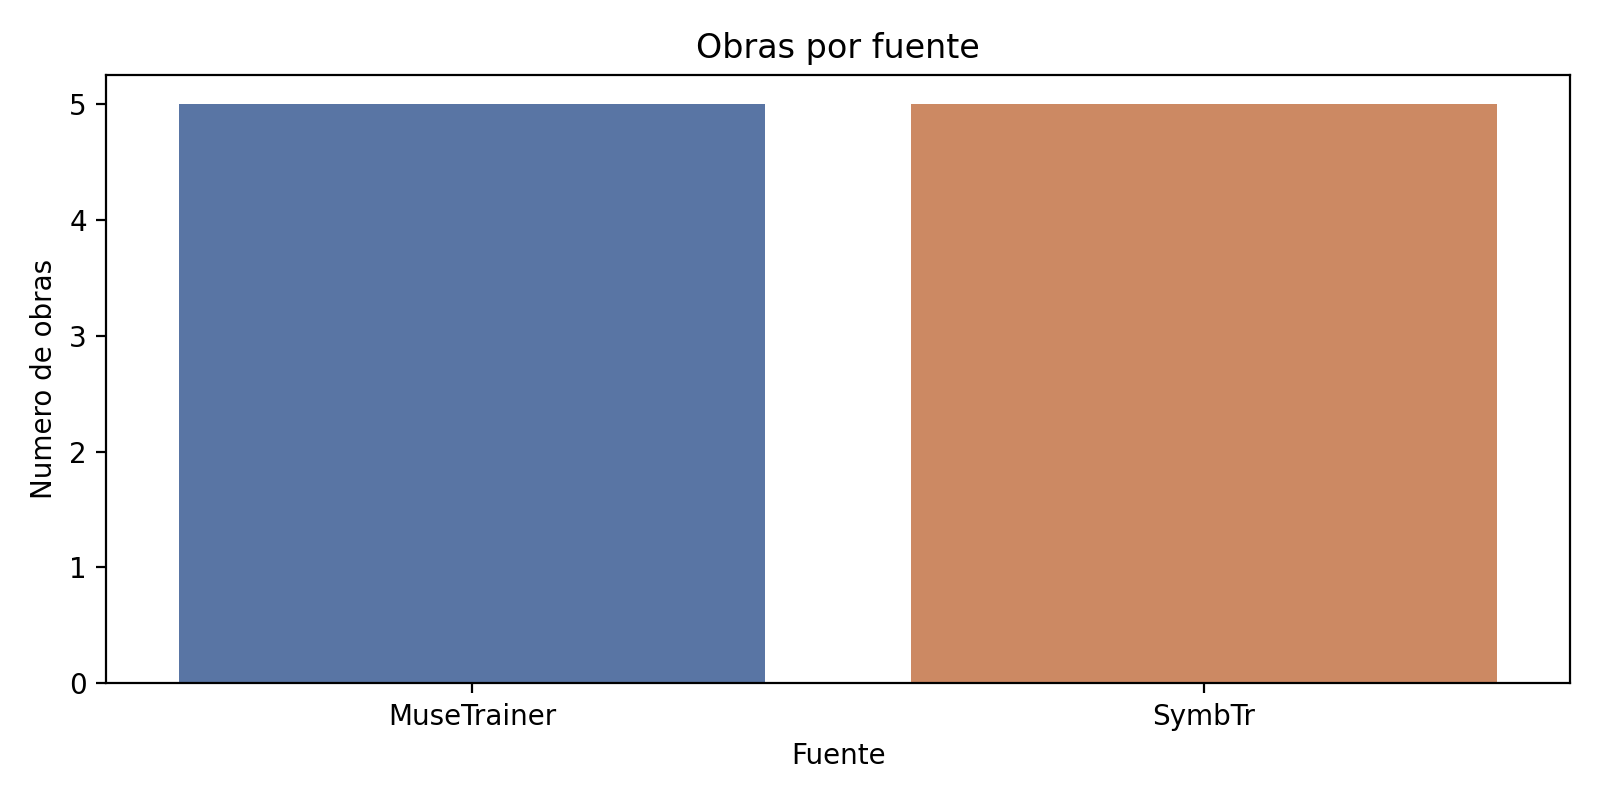

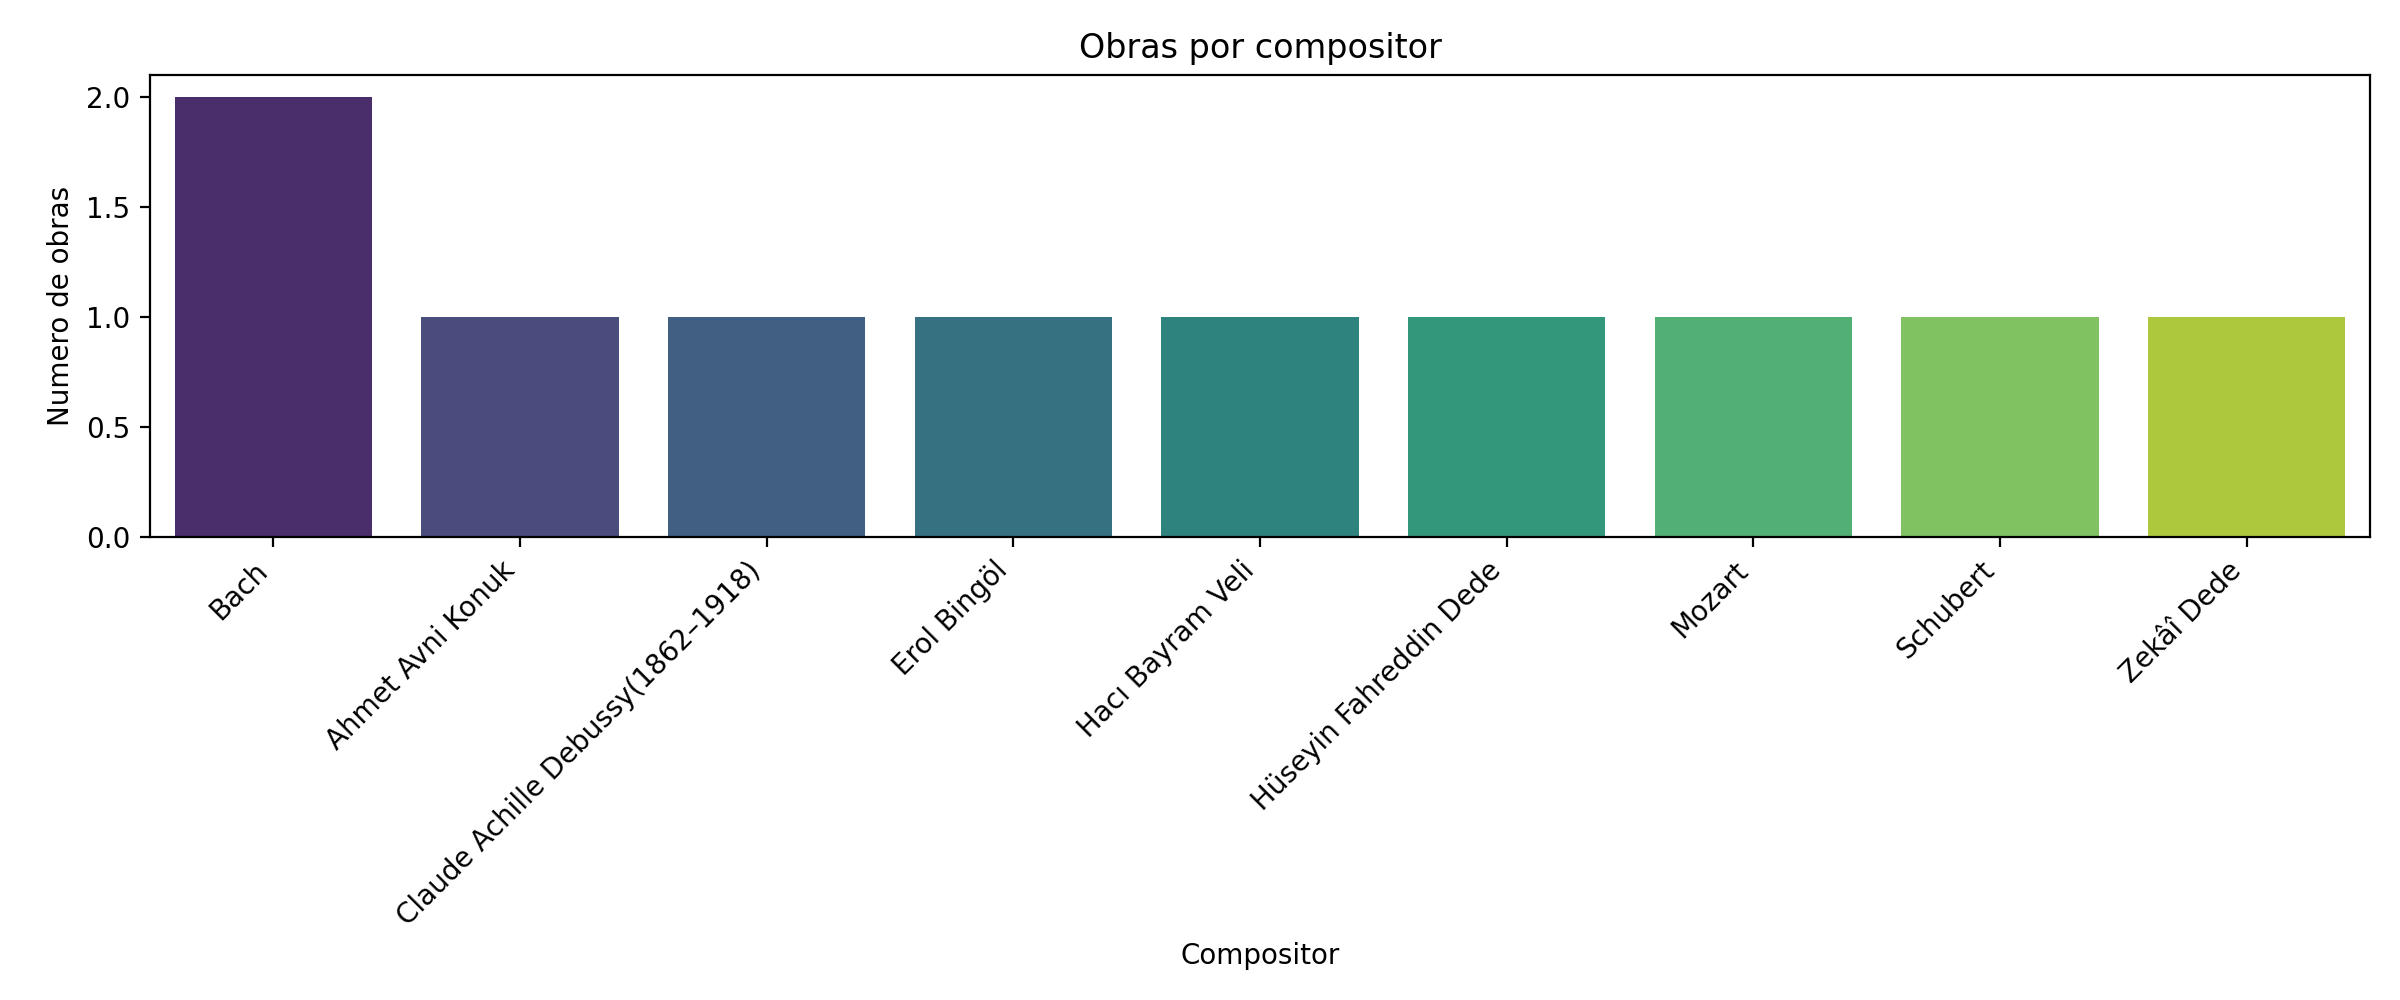

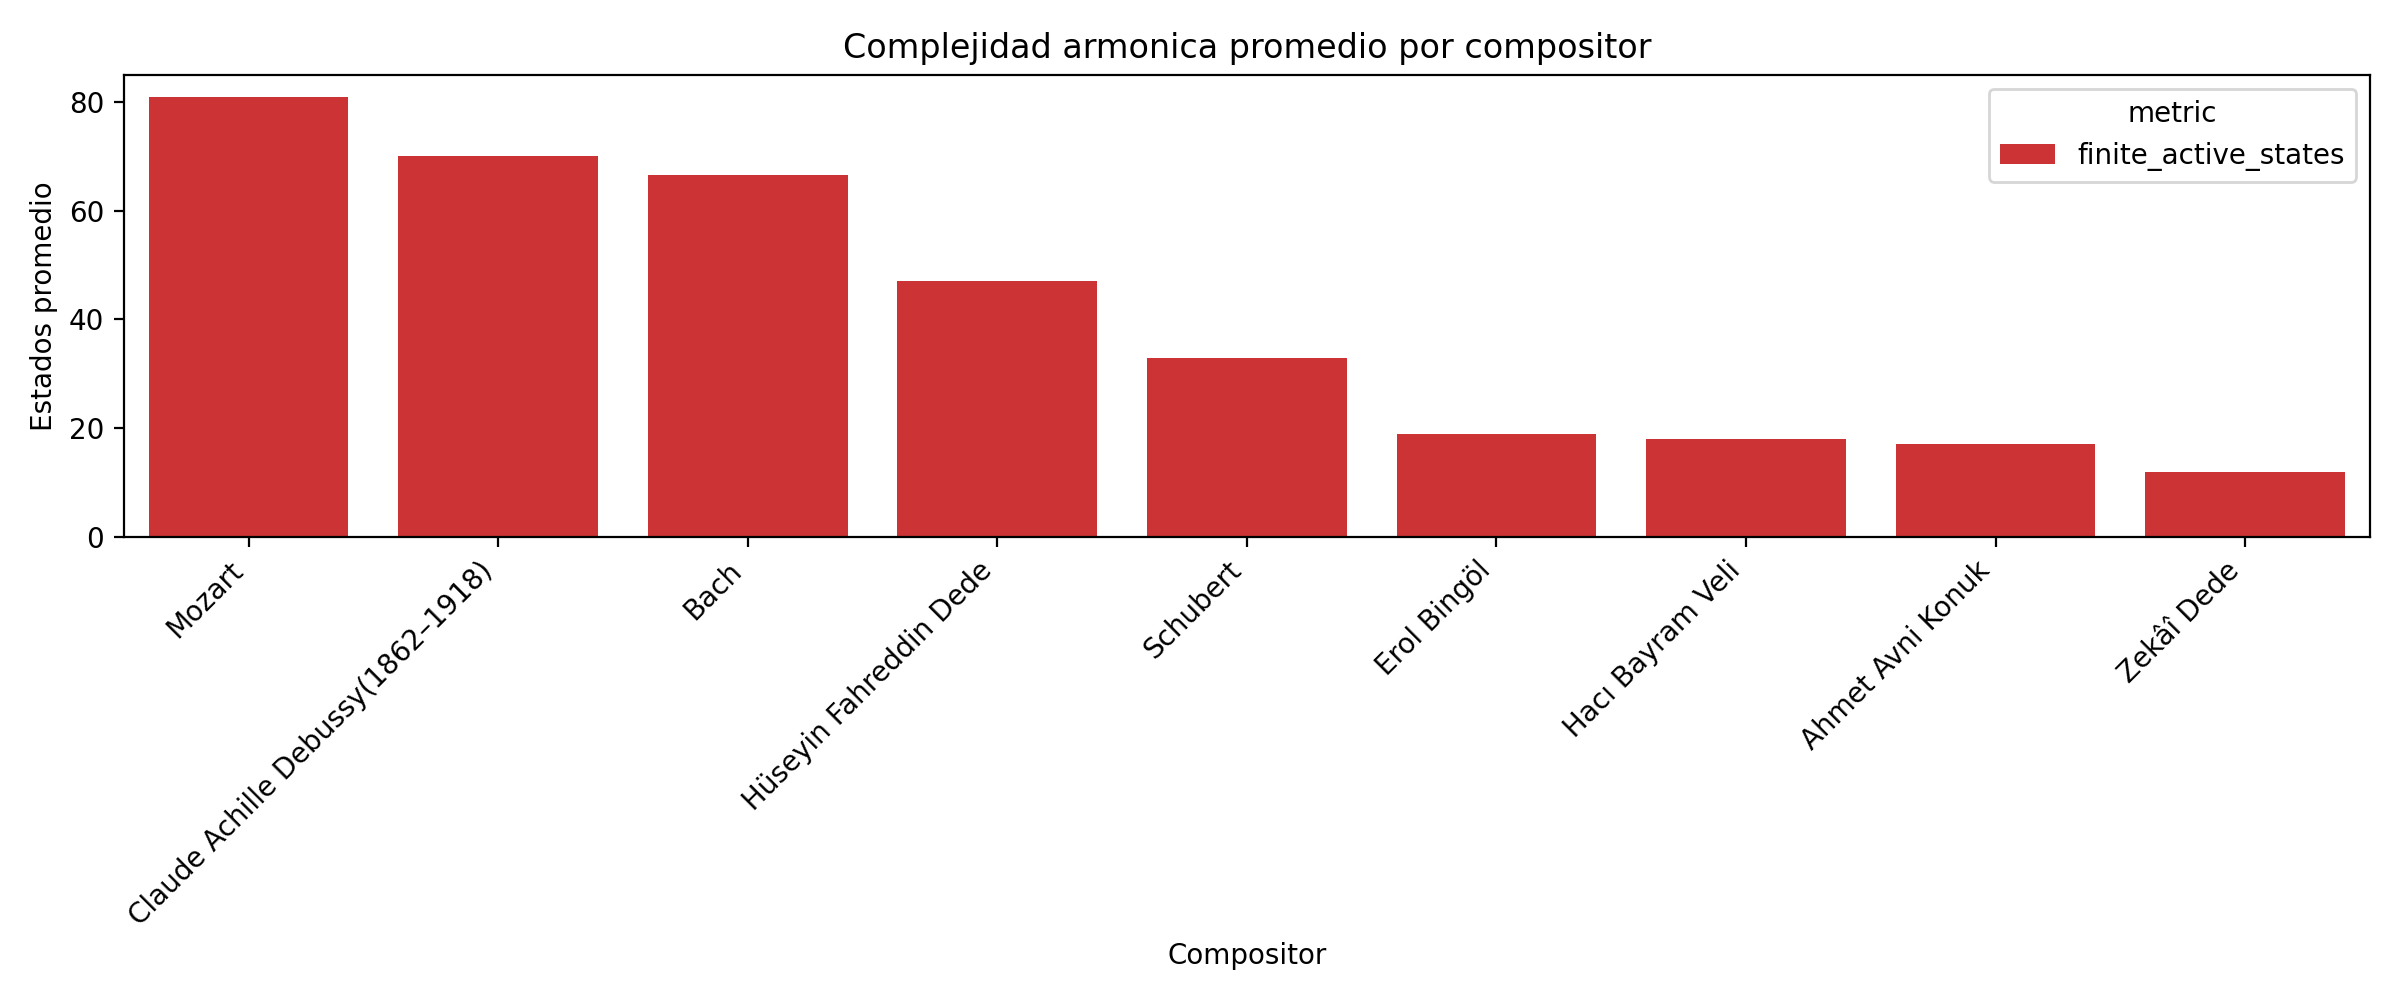

In [5]:
from IPython.display import Image, display

figure_paths = [
    OUTPUT_DIR / 'catalog' / 'figures' / 'catalog_by_source.png',
    OUTPUT_DIR / 'catalog' / 'figures' / 'catalog_by_composer.png',
    OUTPUT_DIR / 'analysis' / 'figures' / 'composer_state_complexity.png',
]

for figure_path in figure_paths:
    if figure_path.exists():
        display(Image(filename=str(figure_path)))